# Kulkarni's Algorithms

This notebook consists of some code that Kulkarni discussed in their paper, including Lattice Qubit, Phase Encoding, and FRQI.

In [1]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, Operator
import matplotlib.pyplot as plt
import numpy as np
import math
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
from qiskit_ibm_runtime import SamplerV2
from qiskit import QuantumRegister, ClassicalRegister

# show qiskit version
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.2.1


## Quantum Lattice Algorithm

In [2]:
def QL_encoder(qc: QuantumCircuit, angles: np.array) :
    for i,ang in enumerate(angles) :
        qc.ry(ang , i)

    return qc

In [3]:
def QL_decoder(counts, probability, output_values):
    # For each qubit : Total count where it has value ‘0 ’
    for item in counts :
        for index, bit in enumerate(item):
            if bit == "0": output_values[index] += counts[item]

    decoded_pixels = []
    # Find value based on the decoding equation 2.1
    for value in output_values:
        probability = value / n_shots
        p = 2 * np.arccos(probability **(1/2))
         # Interpolate back from angles to pixel intensity
        p = np.interp(p,(0, np.pi), (0, 255))
        decoded_pixels.append(p)

    return [float(f"{v:.2f}") for v in decoded_pixels]

Quantum Circuit:


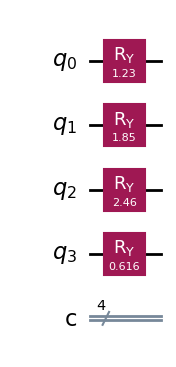

In [4]:
input_vector = np.array([100, 150, 200, 50])

# Map intensities to angles
angles = np.interp(input_vector, (0, 255), (0, np.pi))

qc = QuantumCircuit(len(input_vector), len(input_vector))
qc = QL_encoder(qc, angles)

print("Quantum Circuit:")
qc.draw('mpl', style="iqp")

Unitary matrix:
[[ 0.15578207+0.j -0.11027584+0.j -0.20628879+0.j  0.14602881+0.j
  -0.4420774 +0.j  0.31294011+0.j  0.58540509+0.j -0.41439968+0.j
  -0.04955784+0.j  0.03508127+0.j  0.06562519+0.j -0.04645511+0.j
   0.14063495+0.j -0.09955342+0.j -0.18623077+0.j  0.13183003+0.j]
 [ 0.11027584+0.j  0.15578207+0.j -0.14602881+0.j -0.20628879+0.j
  -0.31294011+0.j -0.4420774 +0.j  0.41439968+0.j  0.58540509+0.j
  -0.03508127+0.j -0.04955784+0.j  0.04645511+0.j  0.06562519+0.j
   0.09955342+0.j  0.14063495+0.j -0.13183003+0.j -0.18623077+0.j]
 [ 0.20628879+0.j -0.14602881+0.j  0.15578207+0.j -0.11027584+0.j
  -0.58540509+0.j  0.41439968+0.j -0.4420774 +0.j  0.31294011+0.j
  -0.06562519+0.j  0.04645511+0.j -0.04955784+0.j  0.03508127+0.j
   0.18623077+0.j -0.13183003+0.j  0.14063495+0.j -0.09955342+0.j]
 [ 0.14602881+0.j  0.20628879+0.j  0.11027584+0.j  0.15578207+0.j
  -0.41439968+0.j -0.58540509+0.j -0.31294011+0.j -0.4420774 +0.j
  -0.04645511+0.j -0.06562519+0.j -0.03508127+0.j -0.0495

None


Statevector as a matrix:
[[0.15578207+0.j]
 [0.11027584+0.j]
 [0.20628879+0.j]
 [0.14602881+0.j]
 [0.4420774 +0.j]
 [0.31294011+0.j]
 [0.58540509+0.j]
 [0.41439968+0.j]
 [0.04955784+0.j]
 [0.03508127+0.j]
 [0.06562519+0.j]
 [0.04645511+0.j]
 [0.14063495+0.j]
 [0.09955342+0.j]
 [0.18623077+0.j]
 [0.13183003+0.j]]


None


Statevector in LaTeX output:


<IPython.core.display.Latex object>

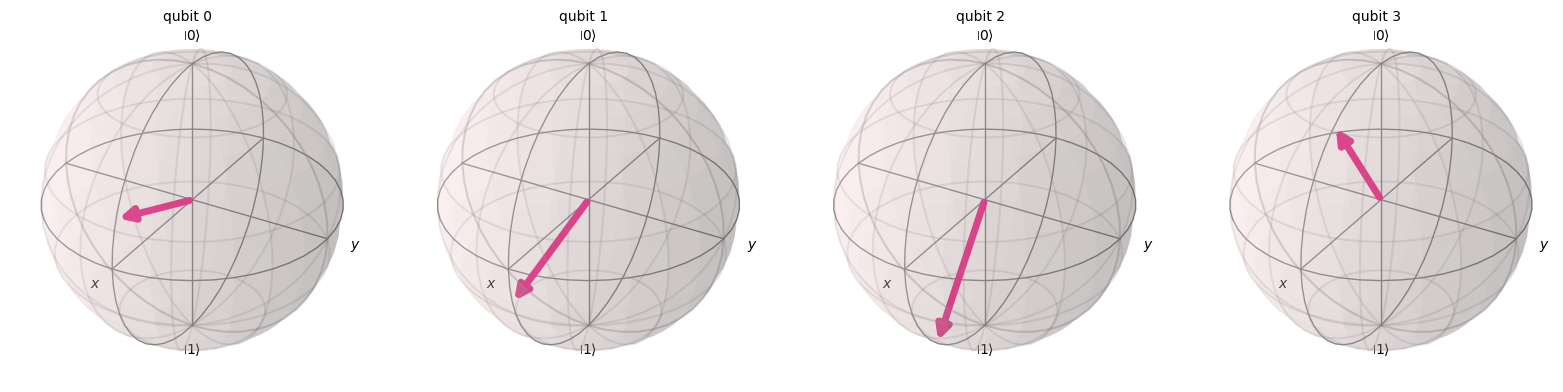

In [5]:
# Get Statevector
state = Statevector.from_instruction(qc)

# Display the Unitary Matrix
unitary = Operator(qc).data
print("Unitary matrix:")
display(print(unitary))

# Display Statevector
matrix_form = np.array(state).reshape(-1, 1)
print("\nStatevector as a matrix:")
display(print(matrix_form))

#LaTeX output
print("\nStatevector in LaTeX output:")
display(state.draw(output='latex'))

# Display Bloch Sphere
plot_bloch_multivector(state)

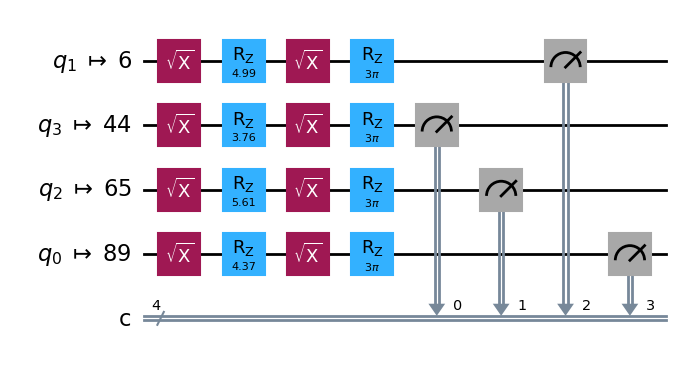

In [6]:
do_measure = True
if do_measure:
  qc.measure (reversed(range(len(input_vector))), range(len(input_vector)))

#backend = AerSimulator()
backend = FakeMarrakesh()
transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl', style="iqp")

Counts: {'1111': 58, '0110': 1401, '1110': 698, '0100': 187, '0001': 9, '1010': 384, '0010': 823, '0111': 141, '0000': 93, '1100': 88, '0011': 81, '1011': 40, '1000': 58, '1101': 7, '0101': 20, '1001': 8}


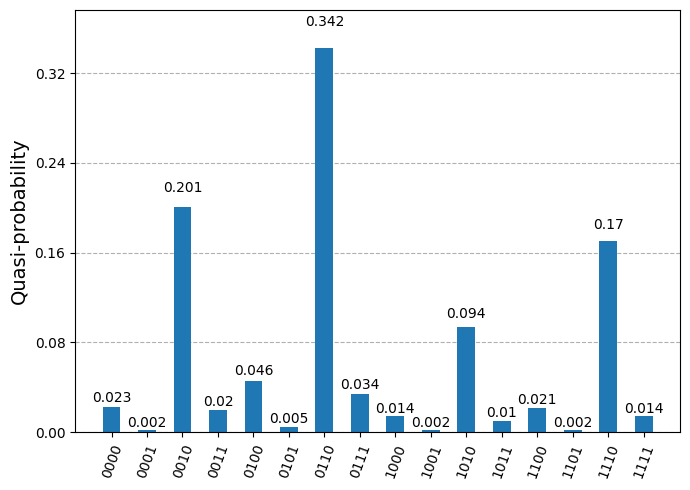

In [7]:
n_shots = 2**12
sampler = SamplerV2(backend)
job = backend.run(transpiled_circuit, shots=n_shots)
result = job.result()

counts = result.get_counts(transpiled_circuit)

print("Counts:", counts)
plot_distribution(counts)

In [8]:
probability = 0
output_values = np.zeros(len(input_vector))

decoded_pixels = QL_decoder(counts, probability, output_values)
print("Input pixel values", input_vector)
print("Decoded pixel values:", decoded_pixels)
print("Output values:", output_values)

error = decoded_pixels - input_vector
percentage_error = (error / input_vector) * 100
for i, (inp, dec, err, perc) in enumerate(zip(input_vector, decoded_pixels, error, percentage_error)):
    print(f"Pixel {i}: Input={inp}, Decoded={dec}, Error={err:.2f}, Pct Error={perc:.2f}%")

Input pixel values [100 150 200  50]
Decoded pixel values: [98.89, 149.65, 198.9, 49.14]
Output values: [2755. 1496.  470. 3732.]
Pixel 0: Input=100, Decoded=98.89, Error=-1.11, Pct Error=-1.11%
Pixel 1: Input=150, Decoded=149.65, Error=-0.35, Pct Error=-0.23%
Pixel 2: Input=200, Decoded=198.9, Error=-1.10, Pct Error=-0.55%
Pixel 3: Input=50, Decoded=49.14, Error=-0.86, Pct Error=-1.72%


## Phase Encoding Algorithm

In [9]:
# inputs : a Qiskit Quantum Circuit and angles based on interpolation
def Ph_encoder(qc: QuantumCircuit, angles: np.array) :
  nq = len(angles)
  for i, ang in enumerate(angles):
    qc.h(i)
    qc.p(ang, i)

  qc.barrier()

  # Apply another Hadamard gate to see the phase effect as probability
  for iq in range(nq):
    qc.h(iq)

  return qc

In [10]:
def marginal_distribution(counts, qubits):
    """Compute marginal counts for a subset of qubits"""
    marg = {}
    for bitstring, count in counts.items():
        key = ''.join(bitstring[::-1][q] for q in qubits)  # reverse because Qiskit uses little-endian
        if key in marg:
            marg[key] += count
        else:
            marg[key] = count
    return marg

def Ph_decoder(counts, probability, output_values):
  reconstruct = []
  # iterating over each qubit and marginalizing over other qubits
  for iq in range (len(input_vector)) :
    marCnt = marginal_distribution(counts, [iq])

    if "1" in marCnt :
      prob = marCnt["1"] / n_shots
    else:
      prob = 0

    ev = 1 - 2* prob
    reconstruct.append(np.arccos(ev))

  # Interpolate back from angles to pixel intensity
  reconstruct = np.interp(reconstruct, (0, np.pi), (0, 255)).astype(int)

  return [float(f"{v:.2f}") for v in reconstruct]


Quantum Circuit:


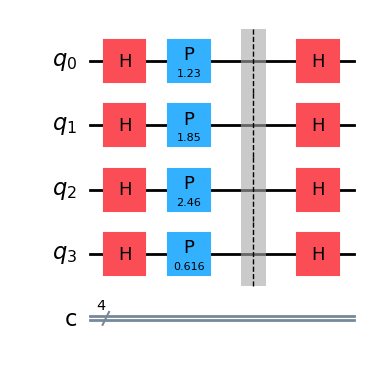

In [11]:
# run PH algorithm
input_vector = np.array([100, 150, 200, 50])

# Map intensities to angles
angles = np.interp(input_vector, (0, 255), (0, np.pi))

qc = QuantumCircuit(len(input_vector), len(input_vector))
qc = Ph_encoder(qc, angles)

print("Quantum Circuit:")
qc.draw('mpl', style="iqp")

Unitary matrix:
[[-0.1554866 +0.00959009j  0.00678868+0.11006668j  0.01269933+0.20589753j
   0.14575185-0.00898967j  0.02721469+0.44123893j  0.31234657-0.01926488j
   0.58429477-0.03603807j -0.02551082-0.4136137j   0.00305083+0.04946385j
   0.03501473-0.00215963j  0.06550072-0.00403995j -0.00285982-0.046367j
   0.14036821-0.00865761j -0.0061286 -0.0993646j  -0.01146453-0.18587755j
  -0.13157999+0.00811558j]
 [ 0.00678868+0.11006668j -0.1554866 +0.00959009j  0.14575185-0.00898967j
   0.01269933+0.20589753j  0.31234657-0.01926488j  0.02721469+0.44123893j
  -0.02551082-0.4136137j   0.58429477-0.03603807j  0.03501473-0.00215963j
   0.00305083+0.04946385j -0.00285982-0.046367j    0.06550072-0.00403995j
  -0.0061286 -0.0993646j   0.14036821-0.00865761j -0.13157999+0.00811558j
  -0.01146453-0.18587755j]
 [ 0.01269933+0.20589753j  0.14575185-0.00898967j -0.1554866 +0.00959009j
   0.00678868+0.11006668j  0.58429477-0.03603807j -0.02551082-0.4136137j
   0.02721469+0.44123893j  0.31234657-0.01926

None


Statevector as a matrix:
[[-0.1554866 +0.00959009j]
 [ 0.00678868+0.11006668j]
 [ 0.01269933+0.20589753j]
 [ 0.14575185-0.00898967j]
 [ 0.02721469+0.44123893j]
 [ 0.31234657-0.01926488j]
 [ 0.58429477-0.03603807j]
 [-0.02551082-0.4136137j ]
 [ 0.00305083+0.04946385j]
 [ 0.03501473-0.00215963j]
 [ 0.06550072-0.00403995j]
 [-0.00285982-0.046367j  ]
 [ 0.14036821-0.00865761j]
 [-0.0061286 -0.0993646j ]
 [-0.01146453-0.18587755j]
 [-0.13157999+0.00811558j]]


None


Statevector in LaTeX output:


<IPython.core.display.Latex object>

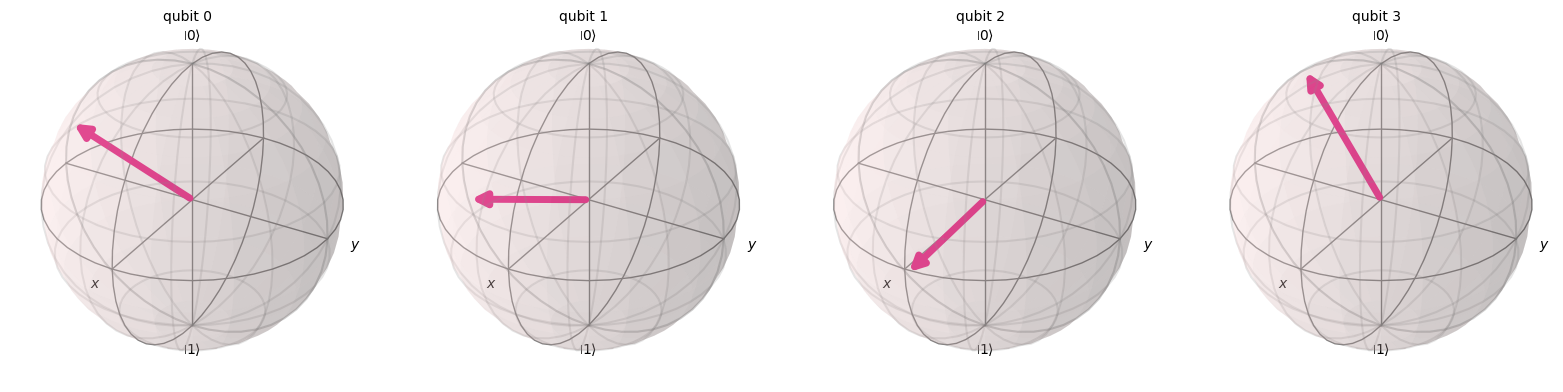

In [12]:
# Get Statevector
state = Statevector.from_instruction(qc)

# Display the Unitary Matrix
unitary = Operator(qc).data
print("Unitary matrix:")
display(print(unitary))

# Display Statevector
matrix_form = np.array(state).reshape(-1, 1)
print("\nStatevector as a matrix:")
display(print(matrix_form))

#LaTeX output
print("\nStatevector in LaTeX output:")
display(state.draw(output='latex'))

# Display Bloch Sphere
plot_bloch_multivector(state)

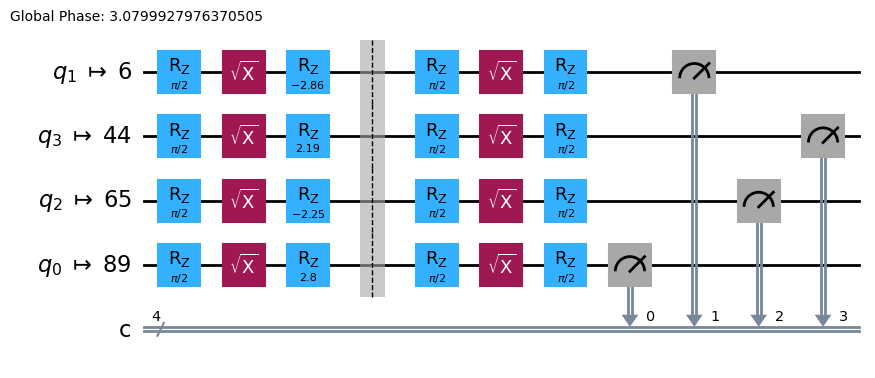

In [13]:
do_measure = True
if do_measure:
  qc.measure(range(len(input_vector)), range(len(input_vector)))

#backend = AerSimulator()
backend = FakeMarrakesh()
transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl', style="iqp")

Counts: {'0111': 732, '0100': 822, '1110': 147, '0101': 394, '0110': 1362, '1000': 18, '0001': 53, '0011': 94, '1111': 72, '1101': 37, '1100': 69, '0010': 168, '0000': 98, '1011': 14, '1010': 12, '1001': 4}


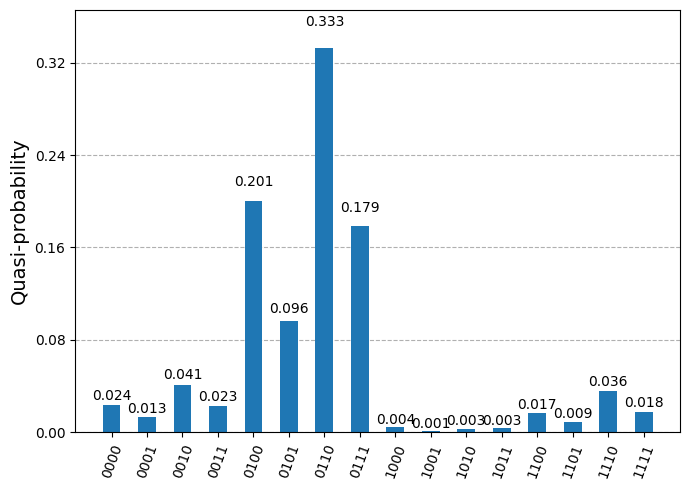

In [14]:
n_shots = 2**12
sampler = SamplerV2(backend)
job = backend.run(transpiled_circuit, shots=n_shots)
result = job.result()

counts = result.get_counts(transpiled_circuit)

print("Counts:", counts)
plot_distribution(counts)

In [15]:
# Call function
decoded_pixels = Ph_decoder(counts, probability, output_values)
print("Input pixel values", input_vector)
print("Decoded pixel values:", decoded_pixels)
print("Output values:", output_values)

error = decoded_pixels - input_vector
percentage_error = (error / input_vector) * 100
for i, (inp, dec, err, perc) in enumerate(zip(input_vector, decoded_pixels, error, percentage_error)):
    print(f"Pixel {i}: Input={inp}, Decoded={dec}, Error={err:.2f}, Pct Error={perc:.2f}%")

Input pixel values [100 150 200  50]
Decoded pixel values: [101.0, 149.0, 199.0, 49.0]
Output values: [2755. 1496.  470. 3732.]
Pixel 0: Input=100, Decoded=101.0, Error=1.00, Pct Error=1.00%
Pixel 1: Input=150, Decoded=149.0, Error=-1.00, Pct Error=-0.67%
Pixel 2: Input=200, Decoded=199.0, Error=-1.00, Pct Error=-0.50%
Pixel 3: Input=50, Decoded=49.0, Error=-1.00, Pct Error=-2.00%


## FRQI Algorithm

In [16]:
# inputs : a Qiskit Quantum Circuit and angles based on interpolation
def QL_encoder(qc: QuantumCircuit, angles: np.array):
  # Step 1
  qc.id(q)
  qc.h(Q)

  controls_ = []
  for i in Q:
    controls_.append(i)

  # Step 2
  for i, theta in enumerate(angles):
    qubit_index_bin = "{0:b}".format(i).zfill(coord_q_num)

    for k,qub_ind in enumerate(qubit_index_bin):
      if int(qub_ind):
        qc.x(Q[k])

    qc.barrier()

    # for coord_or_intns in (0, 1) :
    qc.mcry(theta = 2 * theta, q_controls = controls_, q_target = q[0])

    qc.barrier()

    for k, qub_ind in enumerate(qubit_index_bin):
      if int(qub_ind):
        qc.x(Q[k])

  return qc

In [17]:
def QL_decoder(counts, probability, output_values):
  reconstruct = []
  for i in range(len(input_vector)):
    color_list = [] # stores the values

    # step 1
    for key, count in counts.items():
      int_coord = int(key[1:], 2) # coordinates
      if int_coord == i: # check for qubit in focus
        color_list.append((key[0], count))

    # step 2
    zero_count = 0
    for gvalue, count in color_list:
      # if gvalue == 0, get total for P(j||0>)
      if not int(gvalue) :
        zero_count = zero_count + count

    # step 3
    gvalue = np.arccos((zero_count / sum(count for _, count in color_list))**(1/2))
    reconstruct.append(gvalue)

  # readout is reversed as we used 1 st qubit for gray value instead of last
  reconstruct = list(reversed(np.interp(reconstruct, (0, np.pi / 2), (0 , 255))))

  return [float(f"{v:.2f}") for v in reconstruct]

Quantum Circuit:


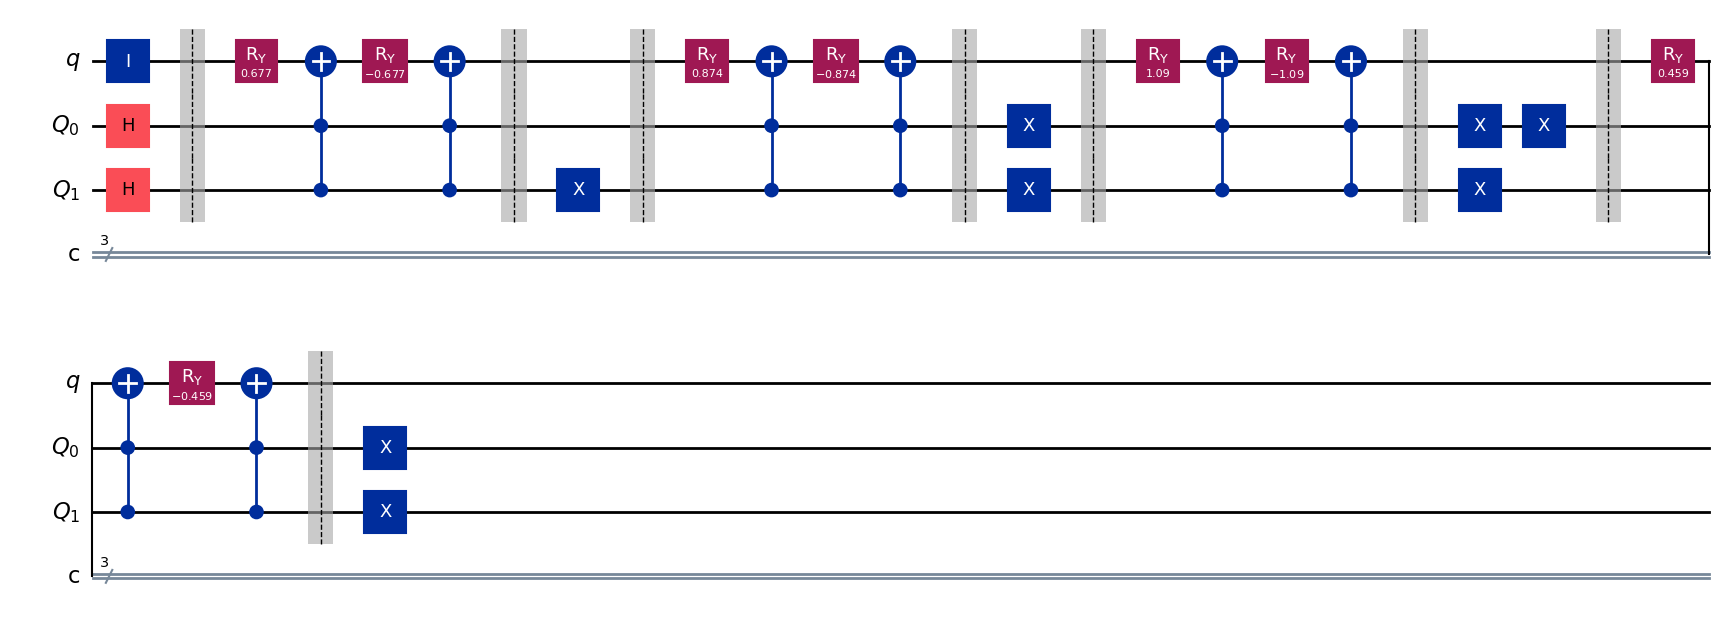

In [18]:
# run FRQI algorithm
input_vector = np.array([100, 150, 200, 50]) # Example grayscale pixels
angles = np.arccos(np.sqrt(1 - np.array(input_vector) / 255))

coord_q_num = int(np.ceil(math.log(len(angles),2)))
q = QuantumRegister(1,"q") # gray value
Q = QuantumRegister(coord_q_num, "Q") # coords
c = ClassicalRegister(Q.size + q.size, "c") # measurement

qc = QuantumCircuit(q, Q, c)
qc = QL_encoder(qc, angles)

print("Quantum Circuit:")
qc.draw('mpl', style="iqp")

Unitary matrix:
[[ 0.44830837+0.j -0.22140372+0.j  0.44830837+0.j -0.22140372+0.j
   0.44830837+0.j -0.22140372+0.j  0.44830837+0.j -0.22140372+0.j]
 [ 0.22140372+0.j  0.44830837+0.j  0.22140372+0.j  0.44830837+0.j
   0.22140372+0.j  0.44830837+0.j  0.22140372+0.j  0.44830837+0.j]
 [ 0.32084447+0.j -0.38348249+0.j -0.32084447+0.j  0.38348249+0.j
   0.32084447+0.j -0.38348249+0.j -0.32084447+0.j  0.38348249+0.j]
 [ 0.38348249+0.j  0.32084447+0.j -0.38348249+0.j -0.32084447+0.j
   0.38348249+0.j  0.32084447+0.j -0.38348249+0.j -0.32084447+0.j]
 [ 0.23221018+0.j -0.44280744+0.j  0.23221018+0.j -0.44280744+0.j
  -0.23221018+0.j  0.44280744+0.j -0.23221018+0.j  0.44280744+0.j]
 [ 0.44280744+0.j  0.23221018+0.j  0.44280744+0.j  0.23221018+0.j
  -0.44280744+0.j -0.23221018+0.j -0.44280744+0.j -0.23221018+0.j]
 [ 0.38982148+0.j -0.31311215+0.j -0.38982148+0.j  0.31311215+0.j
  -0.38982148+0.j  0.31311215+0.j  0.38982148+0.j -0.31311215+0.j]
 [ 0.31311215+0.j  0.38982148+0.j -0.31311215+0.j -0.

None


Statevector as a matrix:
[[0.44830837+0.j]
 [0.22140372+0.j]
 [0.32084447+0.j]
 [0.38348249+0.j]
 [0.23221018+0.j]
 [0.44280744+0.j]
 [0.38982148+0.j]
 [0.31311215+0.j]]


None


Statevector in LaTeX output:


<IPython.core.display.Latex object>

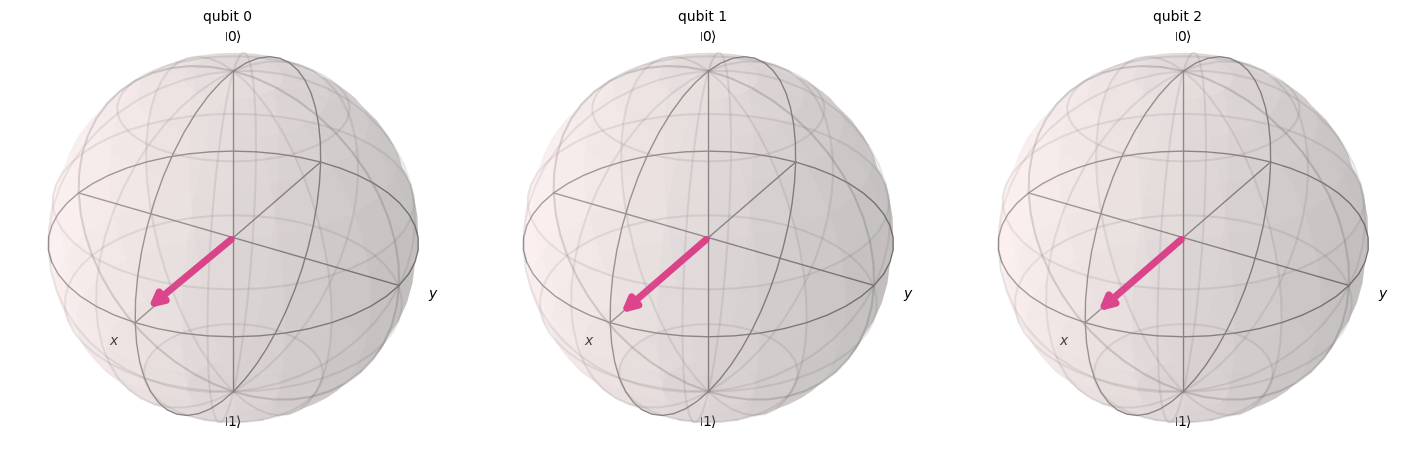

In [19]:
# Get Statevector
state = Statevector.from_instruction(qc)

# Display the Unitary Matrix
unitary = Operator(qc).data
print("Unitary matrix:")
display(print(unitary))

# Display Statevector
matrix_form = np.array(state).reshape(-1, 1)
print("\nStatevector as a matrix:")
display(print(matrix_form))

#LaTeX output
print("\nStatevector in LaTeX output:")
display(state.draw(output='latex'))

# Display Bloch Sphere
plot_bloch_multivector(state)

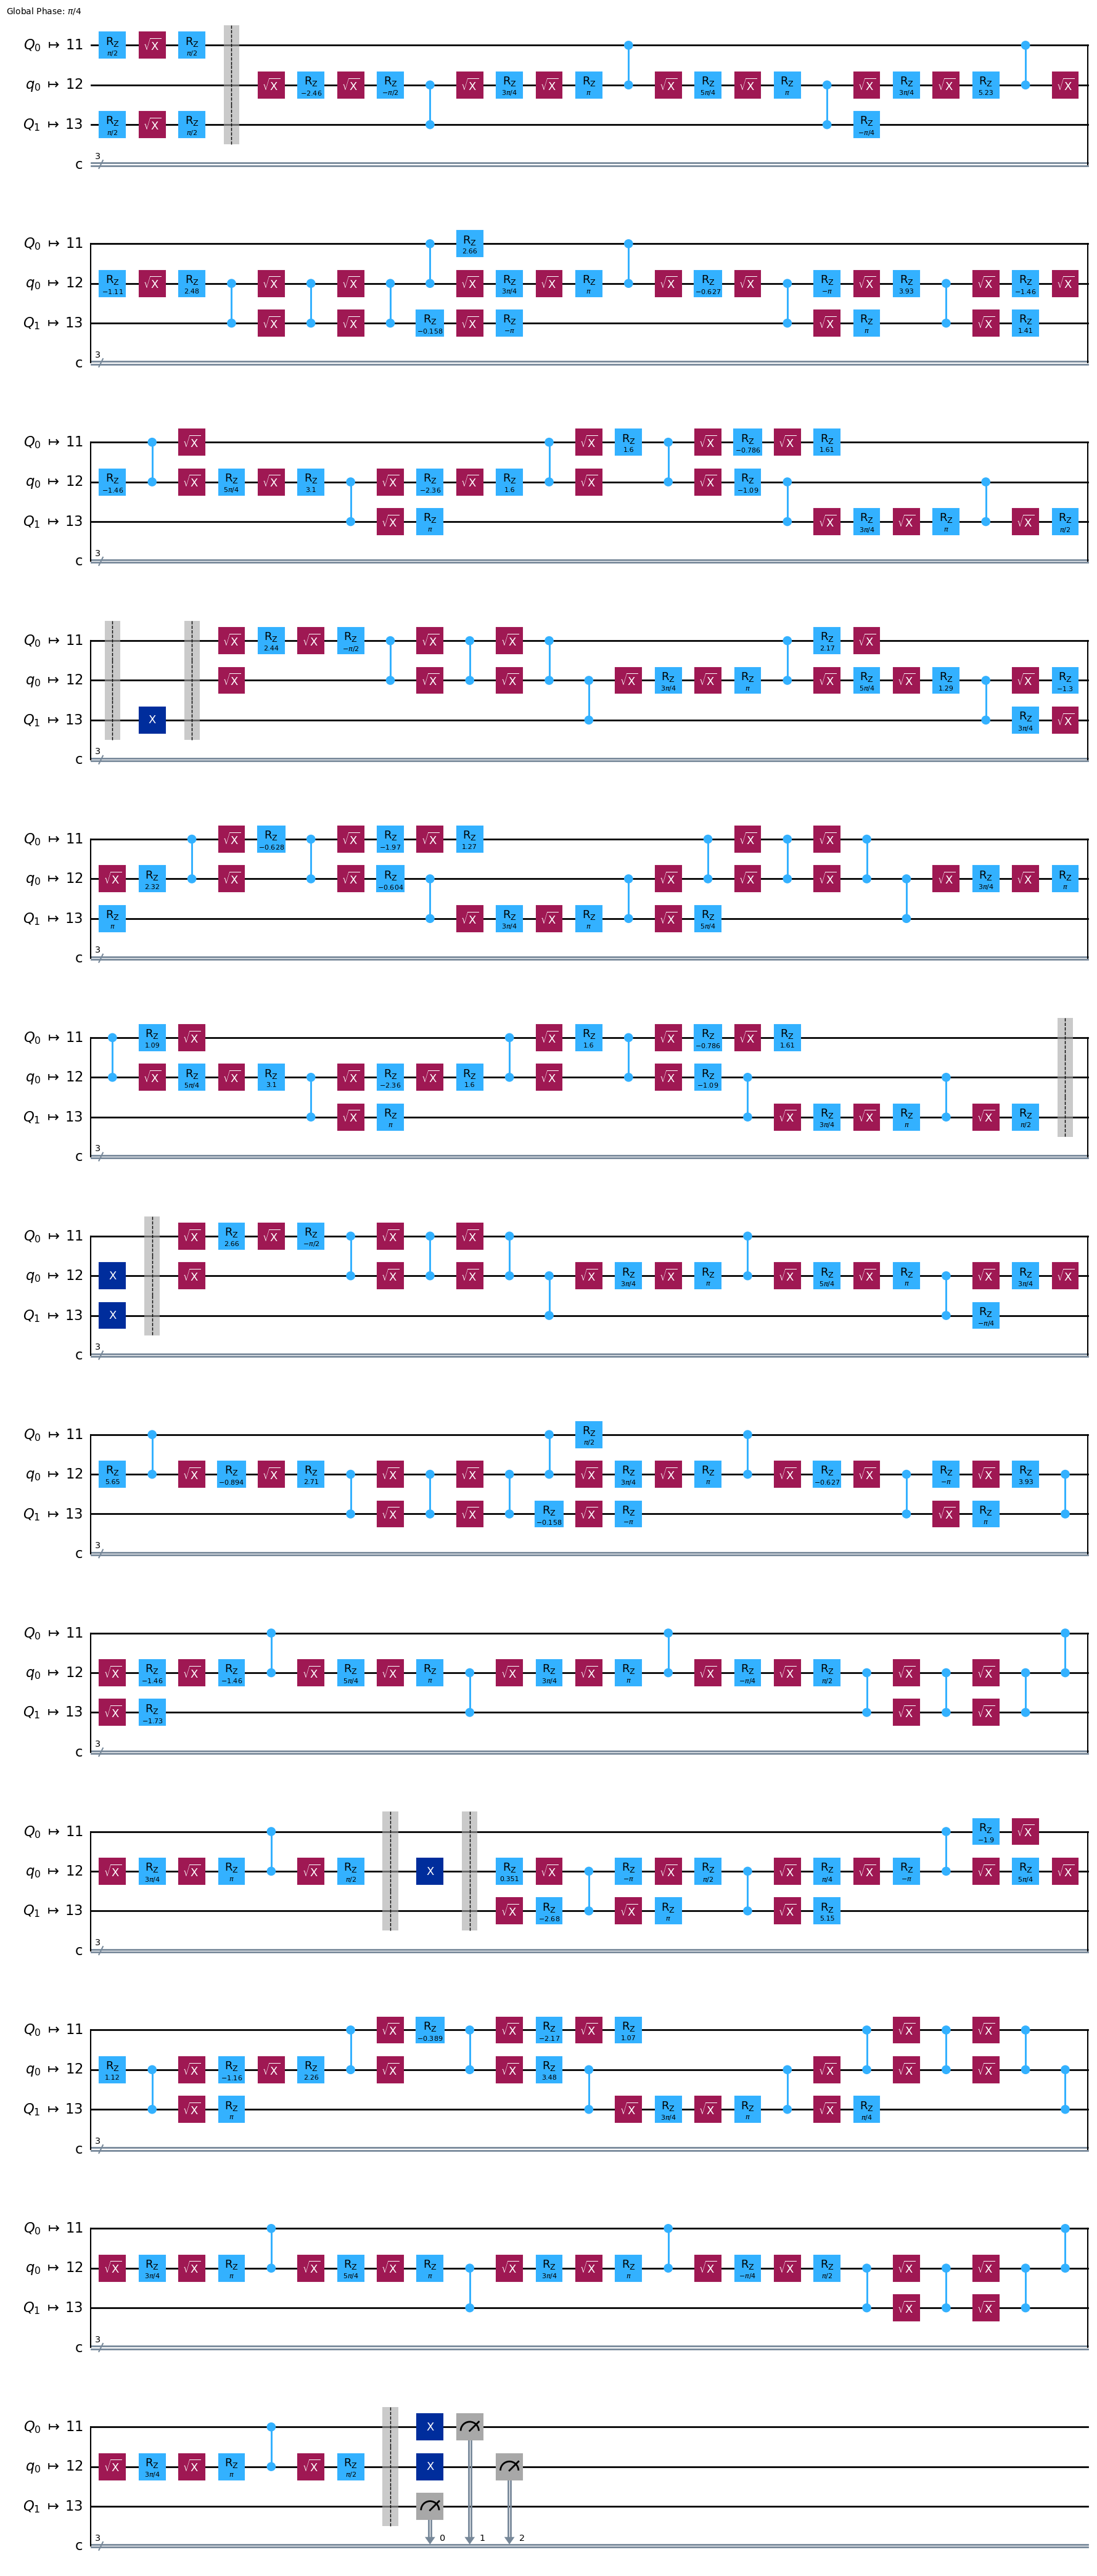

In [20]:
do_measure = True
if do_measure:
  # Measure all qubits
  qc.measure(q[:] + Q[:], c[:])

#backend = AerSimulator()
backend = FakeMarrakesh()
transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl', style="iqp")

Counts: {'001': 250, '110': 586, '010': 422, '111': 411, '101': 770, '000': 803, '011': 581, '100': 273}


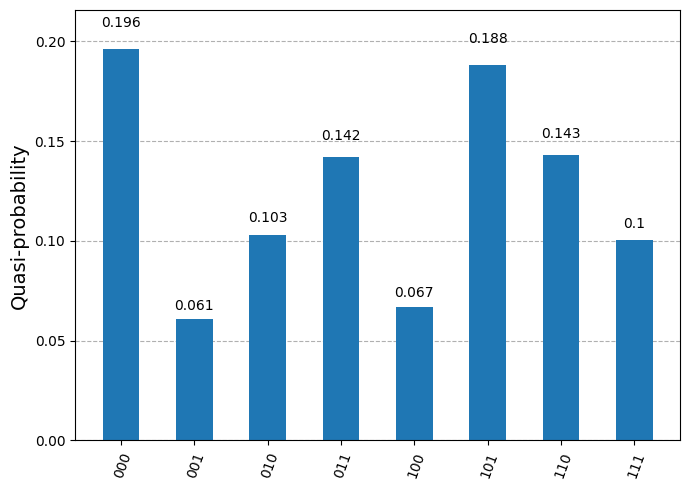

In [21]:
n_shots = 2**12
sampler = SamplerV2(backend)
job = backend.run(transpiled_circuit, shots=n_shots)
result = job.result()

counts = result.get_counts(transpiled_circuit)

print("Counts:", counts)
plot_distribution(counts)

In [22]:
# Call function
decoded_pixels = QL_decoder(counts, probability, output_values)
print("Input pixel values", input_vector)
print("Decoded pixel values:", decoded_pixels)
print("Output values:", output_values)

error = decoded_pixels - input_vector
percentage_error = (error / input_vector) * 100
for i, (inp, dec, err, perc) in enumerate(zip(input_vector, decoded_pixels, error, percentage_error)):
    print(f"Pixel {i}: Input={inp}, Decoded={dec}, Error={err:.2f}, Pct Error={perc:.2f}%")

Input pixel values [100 150 200  50]
Decoded pixel values: [113.52, 140.77, 170.92, 85.7]
Output values: [2755. 1496.  470. 3732.]
Pixel 0: Input=100, Decoded=113.52, Error=13.52, Pct Error=13.52%
Pixel 1: Input=150, Decoded=140.77, Error=-9.23, Pct Error=-6.15%
Pixel 2: Input=200, Decoded=170.92, Error=-29.08, Pct Error=-14.54%
Pixel 3: Input=50, Decoded=85.7, Error=35.70, Pct Error=71.40%
